# Exp09a — M15 Structural Transfer Study

### Bounded Claim Statement

> **This experiment does NOT test strategy profitability or execution feasibility.**
> It tests whether the wick-absorption mechanism from Exp08a (FQR=1.124)
> **survives the timeframe change from M1 to M15**.

**Prior chain:**
- Exp08a: FQR=1.124 [PASS] but Eff.Gap=66.8x [FAIL]. Execution is not the bottleneck.
- Hypothesis: M1=HFT/MM domain (wick absorbed instantly, drift microscopic).
  M15=potential inventory transfer (wick=rebalance, return-to-level=persistent drift).
- If inventory-driven: drift should scale **superlinearly** vs sqrt(15) null.

### 4 Gates (all must pass for Exp09b GO)

| Gate | Criterion | Fail implication |
|------|-----------|-----------------|
| G1 FQR transfer | FQR_M15 > 0.70 | Mechanism is M1-specific HFT artifact |
| G2 Drift scaling | gap_raw < 10x | Scale benefit insufficient |
| G3 Hold persistence | alpha decays slower than M1 | No persistence gain at M15 |
| G4 Fill survivability | P(fill,B) >= 30% | Larger M15 moves gap past limit |

### Failure Taxonomy

| Exp | Failure cause |
|-----|--------------|
| 01-03 | Signal horizon intrinsic ~6min |
| 04-05B | Causal hypothesis false |
| 06a/06a.1 | 97% VWAP drift artifact |
| 07 | P(cont)~48%, E_net<0 |
| 08a | Execution OK (FQR=1.124), M1 scale kills signal (Gap=66.8x) |
| 09a | TBD |

**CRITICAL:** M15 thresholds are calibrated empirically in Cell 4.
Do NOT assume TR/ATR > 2.0 or EER < 0.40 are valid at M15 without checking percentiles.


In [1]:
import hashlib, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M1.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEP = '=' * 68

# M1 reference params (FROZEN from Exp07/08a — do NOT apply at M15 blindly)
M1_ATR_THRESH  = 2.0
M1_EER_LOW     = 0.40
M1_VOL_LOW_PCT = 0.50
M1_FQR_REF     = 1.124    # Exp08a Low+Low Model B@3c
M1_GAP_REF     = 66.8     # Exp08a Eff.Gap
M1_DRIFT_REF   = 0.00001  # ~0.001% Low+Low@3c, Exp08a context

# M15 config (thresholds calibrated in Cell 4)
ATR_WINDOW_M15        = 20
PERCENTILE_WINDOW_M15 = 500
SPLIT_DATE            = pd.Timestamp('2026-03-29', tz='UTC')
FWD_HORIZONS_M15      = [1, 2, 3, 5, 10]
PRIMARY_H             = 3
FILL_HORIZONS         = [1, 3, 5]
FILL_EPSILON          = 0.0001
N_BOOTSTRAP           = 500

# Cost model (same as Exp08a)
TAKER_COST = 0.0008
FQR_GO     = 0.70
GAP_RAW_GO = 10.0   # screening gate (Exp09b will use fill-adjusted 5x)

SPEC = {
    'version': '09a-v1', 'prior': 'Exp08a-3875a863a4fe',
    'objective': 'structural_transfer_m1_to_m15',
    'atr_window_m15': ATR_WINDOW_M15,
}
SPEC_HASH = hashlib.sha256(json.dumps(SPEC, sort_keys=True).encode()).hexdigest()[:12]

print('Cell 2 OK — Exp09a: M15 Structural Transfer Study')
print(f'SPEC_HASH: {SPEC_HASH}')
print(f'Split date: {SPLIT_DATE.date()}')
print(f'Gates: FQR>{FQR_GO}  gap_raw<{GAP_RAW_GO}x  hold_persist  fill>=30%')
print('M15 ATR/EER thresholds -> calibrated empirically in Cell 4')


Cell 2 OK — Exp09a: M15 Structural Transfer Study
SPEC_HASH: 89f1a4e54b3a
Split date: 2026-03-29
Gates: FQR>0.7  gap_raw<10.0x  hold_persist  fill>=30%
M15 ATR/EER thresholds -> calibrated empirically in Cell 4


In [2]:
# Load M1 + resample to M15 + base features
df_m1 = pd.read_csv(DATA_FILE)
df_m1['open_time'] = pd.to_datetime(df_m1['open_time'], unit='ms', utc=True)
df_m1 = df_m1.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_m1[col] = df_m1[col].astype(float)

print(f'M1: {len(df_m1):,} candles | {df_m1["open_time"].iloc[0].date()} -> {df_m1["open_time"].iloc[-1].date()}')

# Resample M1 -> M15
df = (df_m1.set_index('open_time')
      .resample('15min')
      .agg({'open':'first','high':'max','low':'min','close':'last','volume':'sum'})
      .dropna(subset=['open','close'])
      .reset_index())
df['date'] = df['open_time'].dt.date

print(f'M15: {len(df):,} candles | compression ratio={len(df_m1)/len(df):.1f}x (expected ~15)')

# ATR
prev_close = df['close'].shift(1)
df['tr'] = np.maximum(df['high'] - df['low'],
           np.maximum((df['high'] - prev_close).abs(),
                      (df['low']  - prev_close).abs()))
df['atr']      = df['tr'].rolling(ATR_WINDOW_M15, min_periods=ATR_WINDOW_M15 // 2).mean()
df['tr_ratio'] = df['tr'] / df['atr']

# EER
body         = (df['close'] - df['open']).abs()
candle_range = (df['high'] - df['low']).replace(0, np.nan)
df['eer']    = (body / candle_range).clip(0, 1)
df['dir_sign'] = np.where(df['close'] >= df['open'], 1.0, -1.0)

# Volume percentile
df['vol_pct'] = df['volume'].rolling(PERCENTILE_WINDOW_M15, min_periods=50).rank(pct=True)

# Split
df['split'] = np.where(df['open_time'] < SPLIT_DATE, 'train', 'holdout')
train   = df[df['split'] == 'train'].copy()
holdout = df[df['split'] == 'holdout'].copy()

print(f'Train:   {len(train):,} M15 candles')
print(f'Holdout: {len(holdout):,} M15 candles')
print('Cell 3 OK')


M1: 518,401 candles | 2025-05-29 -> 2026-05-24
M15: 34,561 candles | compression ratio=15.0x (expected ~15)
Train:   29,096 M15 candles
Holdout: 5,465 M15 candles
Cell 3 OK


In [3]:
# M15 Distribution Analysis + Threshold Calibration
print(SEP)
print('CELL 4 - M15 DISTRIBUTION ANALYSIS + THRESHOLD CALIBRATION')
print('Do NOT apply M1 thresholds without verifying their M15 percentile equivalent')
print(SEP)

# TR/ATR
print('\nTR/ATR distribution (M15 train):')
tr_pcts = {}
for p in [50, 75, 90, 95, 97, 99]:
    v = train['tr_ratio'].quantile(p / 100)
    tr_pcts[p] = v
    print(f'  P{p:2d}: {v:.3f}')
p_m1_thresh_at_m15 = (train['tr_ratio'] > M1_ATR_THRESH).mean()
print(f'  P(TR/ATR > {M1_ATR_THRESH} [M1 thresh]) at M15: {p_m1_thresh_at_m15*100:.2f}%')

# EER
print('\nEER distribution (M15 train):')
eer_pcts = {}
for p in [10, 25, 40, 50, 60, 75, 90]:
    v = train['eer'].quantile(p / 100)
    eer_pcts[p] = v
    print(f'  P{p:2d}: {v:.3f}')
p_m1_eer_at_m15 = (train['eer'] < M1_EER_LOW).mean()
print(f'  P(EER < {M1_EER_LOW} [M1 EER_LOW]) at M15: {p_m1_eer_at_m15*100:.1f}%  (M1: ~40%)')

# Vol percentile: uniform by construction, threshold 0.50 is valid at any TF
print('\nVol percentile: uniform by construction -> M1 threshold (0.50) valid at M15.')

# Set M15-calibrated thresholds using percentile matching
ATR_THRESH_M15  = tr_pcts[90]   # P90 = same relative rarity as M1 burst events
EER_LOW_M15     = eer_pcts[40]  # P40 = same relative bucket as M1 Low bucket
VOL_LOW_PCT_M15 = 0.50

print(f'\nCalibrated M15 thresholds:')
print(f'  ATR_THRESH_M15  = {ATR_THRESH_M15:.4f}  (P90 of M15 TR/ATR)')
print(f'  EER_LOW_M15     = {EER_LOW_M15:.4f}  (P40 of M15 EER)')
print(f'  VOL_LOW_PCT_M15 = {VOL_LOW_PCT_M15}')
print()
delta_atr = abs(ATR_THRESH_M15 - M1_ATR_THRESH)
print(f'  ATR threshold delta vs M1: {delta_atr:.3f} '
      f'({"SIMILAR" if delta_atr < 0.3 else "DIFFERENT - naive M1 reuse would be invalid"})')
print('Cell 4 OK')


CELL 4 - M15 DISTRIBUTION ANALYSIS + THRESHOLD CALIBRATION
Do NOT apply M1 thresholds without verifying their M15 percentile equivalent

TR/ATR distribution (M15 train):
  P50: 0.875
  P75: 1.223
  P90: 1.703
  P95: 2.125
  P97: 2.450
  P99: 3.211
  P(TR/ATR > 2.0 [M1 thresh]) at M15: 6.13%

EER distribution (M15 train):
  P10: 0.119
  P25: 0.276
  P40: 0.417
  P50: 0.506
  P60: 0.593
  P75: 0.725
  P90: 0.876
  P(EER < 0.4 [M1 EER_LOW]) at M15: 38.1%  (M1: ~40%)

Vol percentile: uniform by construction -> M1 threshold (0.50) valid at M15.

Calibrated M15 thresholds:
  ATR_THRESH_M15  = 1.7027  (P90 of M15 TR/ATR)
  EER_LOW_M15     = 0.4167  (P40 of M15 EER)
  VOL_LOW_PCT_M15 = 0.5

  ATR threshold delta vs M1: 0.297 (SIMILAR)
Cell 4 OK


In [4]:
# Apply M15 thresholds + forward returns + fill flags + bin counts
train['eer_bucket'] = pd.cut(train['eer'],
    bins=[-0.01, EER_LOW_M15, 0.65, 1.01], labels=['Low','Med','High'])
train['vol_bucket'] = pd.cut(train['vol_pct'],
    bins=[-0.01, VOL_LOW_PCT_M15, 0.90, 1.01], labels=['Low','Med','High'])
train['bin'] = train['eer_bucket'].astype(str) + '+' + train['vol_bucket'].astype(str)

# Forward returns (anti-leakage: groupby date)
MAX_H = max(FWD_HORIZONS_M15)
for h in range(1, MAX_H + 1):
    train[f'fwd_c{h}'] = train.groupby('date')['close'].shift(-h)
train['fwd_open1'] = train.groupby('date')['open'].shift(-1)

for h in FILL_HORIZONS:
    train[f'fwd_min_low_{h}']  = train['low'].rolling(h).min().shift(-h)
    train[f'fwd_max_high_{h}'] = train['high'].rolling(h).max().shift(-h)

for h in FWD_HORIZONS_M15:
    train[f'cont_{h}c'] = (train[f'fwd_c{h}'] - train['close']) * train['dir_sign'] / train['close']

# Burst + signal
train['is_burst']  = train['tr_ratio'] > ATR_THRESH_M15
train['is_signal'] = train['is_burst'] & (train['bin'] == 'Low+Low')

sig_all  = train[train['is_burst']].dropna(subset=[f'cont_{PRIMARY_H}c']).copy().reset_index(drop=True)
sig_prim = train[train['is_signal']].dropna(subset=[f'cont_{PRIMARY_H}c']).copy().reset_index(drop=True)

# Fill flags
def _fill_flags(subset):
    lm  = (subset['dir_sign'] == 1.0).values
    sm  = (subset['dir_sign'] == -1.0).values
    cl0 = subset['close'].values
    eps = cl0 * FILL_EPSILON
    for h in FILL_HORIZONS:
        minl = subset[f'fwd_min_low_{h}'].values
        maxh = subset[f'fwd_max_high_{h}'].values
        subset[f'fill_B_{h}c'] = (lm & (minl <= cl0)) | (sm & (maxh >= cl0))
        subset[f'fill_C_{h}c'] = (lm & (minl < cl0 - eps)) | (sm & (maxh > cl0 + eps))

_fill_flags(sig_all)
_fill_flags(sig_prim)

n_burst = train['is_burst'].sum()
n_sig   = train['is_signal'].sum()
print(f'Burst events (TR/ATR > {ATR_THRESH_M15:.3f}): {n_burst:,}  ({n_burst/len(train)*100:.1f}% of M15 train)')
print(f'EER=Low+Vol=Low signals:  {n_sig}  ({n_sig/n_burst*100:.1f}% of bursts)  [sig_all={len(sig_all)}]')
print()
print('Bin counts (burst events only):')
for b, cnt in train[train['is_burst']]['bin'].value_counts().sort_index().items():
    flag = '  <- PRIMARY' if b == 'Low+Low' else ''
    print(f'  {b}: n={cnt:,}{flag}')
print()
if n_sig < 30:
    print('WARN: Low+Low n < 30 -- very wide CI. Results indicative only.')
elif n_sig < 100:
    print(f'CAUTION: Low+Low n={n_sig} -- results valid but CI wide.')
else:
    print(f'OK: Low+Low n={n_sig}')
print('Cell 5 OK')


Burst events (TR/ATR > 1.703): 2,909  (10.0% of M15 train)
EER=Low+Vol=Low signals:  63  (2.2% of bursts)  [sig_all=2870]

Bin counts (burst events only):
  High+High: n=616
  High+Low: n=210
  High+Med: n=603
  Low+High: n=319
  Low+Low: n=63  <- PRIMARY
  Low+Med: n=292
  Med+High: n=369
  Med+Low: n=86
  Med+Med: n=345

CAUTION: Low+Low n=63 -- results valid but CI wide.
Cell 5 OK


GATE 3 - ALPHA HALF-LIFE (hold persistence)
Key question: does alpha decay SLOWER at M15 than at M1?
M1 ref: Low+Low P(cont@3c)=54.6%, fast decay pattern

  H (M15c)   P(cont) ALL   P(cont) Low+Low    drift ALL%    drift Low+Low%
        1c         45.2%             42.6%     -0.00876%         -0.02143%
        2c         47.7%             44.3%     -0.00358%         -0.04645%
        3c         47.6%             45.9%     -0.00150%         -0.05847%
        5c         48.5%             56.1%     +0.00011%         -0.01569%
       10c         48.2%             58.2%     +0.01485%         +0.01833%

  P(cont) decay Low+Low: h=1 (42.6%) -> h=5 (56.1%)  decay=-13.5pp
  M1 reference: ~54% at 3c, decays fast after -> plateau or growth here = persistence
  PERSISTENT -- Gate 3 candidate PASS


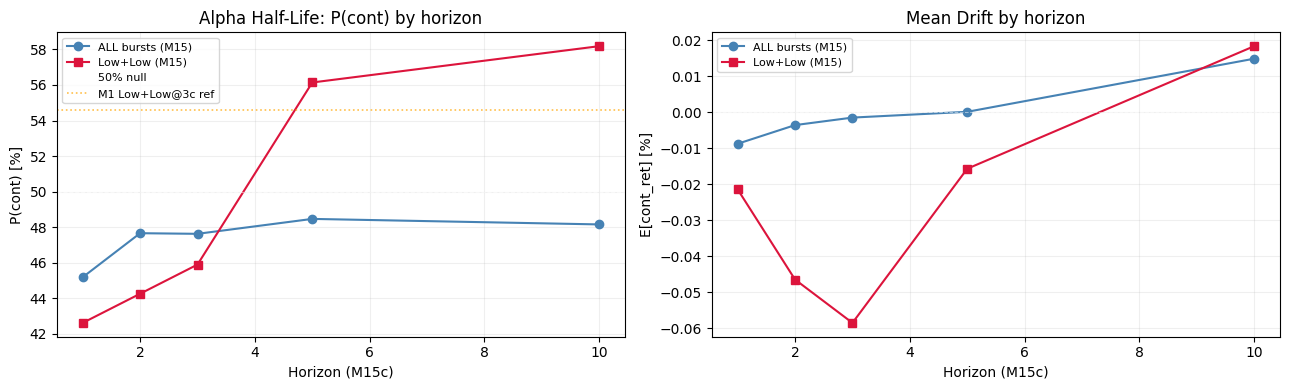

Cell 6 OK


In [5]:
# Gate 3 -- Alpha Half-Life Curves (hold persistence)
print(SEP)
print('GATE 3 - ALPHA HALF-LIFE (hold persistence)')
print('Key question: does alpha decay SLOWER at M15 than at M1?')
print('M1 ref: Low+Low P(cont@3c)=54.6%, fast decay pattern')
print(SEP)

print(f'\n  {"H (M15c)":>8}  {"P(cont) ALL":>12}  {"P(cont) Low+Low":>16}  {"drift ALL%":>12}  {"drift Low+Low%":>16}')

pcont_all_list = []; pcont_prim_list = []
drift_all_list = []; drift_prim_list = []

for h in FWD_HORIZONS_M15:
    col  = f'cont_{h}c'
    pc_a = (sig_all[col].dropna()  > 0).mean() * 100
    d_a  =  sig_all[col].mean() * 100
    pcont_all_list.append(pc_a); drift_all_list.append(d_a)
    if len(sig_prim) >= 10:
        pc_p = (sig_prim[col].dropna() > 0).mean() * 100
        d_p  =  sig_prim[col].mean() * 100
    else:
        pc_p = np.nan; d_p = np.nan
    pcont_prim_list.append(pc_p); drift_prim_list.append(d_p)
    print(f'  {h:>7}c  {pc_a:>11.1f}%  {pc_p:>15.1f}%  {d_a:>+11.5f}%  {d_p:>+15.5f}%')

print()
h1_idx = FWD_HORIZONS_M15.index(1)
h5_idx = FWD_HORIZONS_M15.index(5)
pc_1   = pcont_prim_list[h1_idx]
pc_5   = pcont_prim_list[h5_idx]
if not (np.isnan(pc_1) or np.isnan(pc_5)):
    decay = pc_1 - pc_5
    print(f'  P(cont) decay Low+Low: h=1 ({pc_1:.1f}%) -> h=5 ({pc_5:.1f}%)  decay={decay:+.1f}pp')
    print(f'  M1 reference: ~54% at 3c, decays fast after -> plateau or growth here = persistence')
    if decay < 2.0 and pc_5 > 50.5:
        print('  PERSISTENT -- Gate 3 candidate PASS')
    elif decay < 5.0:
        print('  MODERATE decay -- borderline Gate 3')
    else:
        print('  FAST decay -- same pattern as M1 -- Gate 3 likely FAIL')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(FWD_HORIZONS_M15, pcont_all_list, 'o-', color='steelblue', label='ALL bursts (M15)')
if not all(np.isnan(x) for x in pcont_prim_list):
    ax.plot(FWD_HORIZONS_M15, pcont_prim_list, 's-', color='crimson', label='Low+Low (M15)')
ax.axhline(50,   color='white',  ls='--', lw=0.8, alpha=0.5, label='50% null')
ax.axhline(54.6, color='orange', ls=':',  lw=1.2, alpha=0.7, label='M1 Low+Low@3c ref')
ax.set_title('Alpha Half-Life: P(cont) by horizon'); ax.set_xlabel('Horizon (M15c)')
ax.set_ylabel('P(cont) [%]'); ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes[1]
ax.plot(FWD_HORIZONS_M15, drift_all_list, 'o-', color='steelblue', label='ALL bursts (M15)')
if not all(np.isnan(x) for x in drift_prim_list):
    ax.plot(FWD_HORIZONS_M15, drift_prim_list, 's-', color='crimson', label='Low+Low (M15)')
ax.axhline(0, color='white', ls='--', lw=0.7, alpha=0.5)
ax.set_title('Mean Drift by horizon'); ax.set_xlabel('Horizon (M15c)')
ax.set_ylabel('E[cont_ret] [%]'); ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09a_alpha_halflife.png', dpi=100, bbox_inches='tight')
plt.show()
print('Cell 6 OK')


In [6]:
# Gate 1 -- FQR Transfer
print(SEP)
print('GATE 1 - FQR TRANSFER')
print('Does anti-adverse selection (FQR>1.0) survive at M15?')
print(f'M1 reference: FQR={M1_FQR_REF} (Model B@{PRIMARY_H}c, Low+Low, Exp08a)')
print(SEP)

ret_col = f'cont_{PRIMARY_H}c'

def bootstrap_fqr(ret_arr, fill_arr, n_boot=N_BOOTSTRAP):
    boot = []
    n    = len(ret_arr)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        sr  = ret_arr[idx].astype(float); sf = fill_arr[idx]
        valid = ~np.isnan(sr)
        if valid.sum() == 0: continue
        e_s = sr[valid].mean()
        e_f = sr[sf & valid]
        if abs(e_s) > 1e-10 and len(e_f) > 0:
            boot.append(e_f.mean() / e_s)
    return (np.percentile(boot, 2.5), np.percentile(boot, 97.5)) if len(boot) > 10 else (np.nan, np.nan)

for label, subset in [
    ('ALL burst events (M15)',          sig_all),
    ('EER=Low+Vol=Low (M15, primary)', sig_prim),
]:
    ret_arr = subset[ret_col].values.astype(float)
    e_sig   = np.nanmean(ret_arr)
    print(f'\n  {label} (n={len(subset)}):')
    print(f'  E[ret|signal] = {e_sig*100:+.5f}%')
    print(f'  {"Model":<8}  {"P(fill)":>8}  {"n_filled":>9}  {"E[ret|fill]":>12}  {"FQR":>8}  {"95%CI":>16}  {"M1ref":>7}  Flag')
    for h in FILL_HORIZONS:
        for m in ['B', 'C']:
            fc = f'fill_{m}_{h}c'
            if fc not in subset.columns: continue
            fill_arr = subset[fc].values.astype(bool)
            valid    = ~np.isnan(ret_arr)
            ret_f    = ret_arr[fill_arr & valid]
            if len(ret_f) < 3: continue
            e_fil = ret_f.mean()
            fqr   = e_fil / e_sig if abs(e_sig) > 1e-10 else np.nan
            ci_lo, ci_hi = bootstrap_fqr(ret_arr, fill_arr)
            m1_ref = f'{M1_FQR_REF}' if (m == 'B' and h == PRIMARY_H) else '---'
            flag   = 'FAIL(FQR<0.70)' if (not np.isnan(fqr) and fqr < FQR_GO) else ('OK' if not np.isnan(fqr) else 'N/A')
            print(f'  {m}@{h}c    {fill_arr.mean()*100:>7.1f}%  {len(ret_f):>9}  '
                  f'{e_fil*100:>+11.5f}%  {fqr:>8.3f}  [{ci_lo:.2f},{ci_hi:.2f}]  {m1_ref:>7}  {flag}')

print()
print('  FQR > 1.0 = anti-adverse selection preserved -> mechanism survives TF change')
print('  FQR 0.7-1.0 = weakened but viable')
print('  FQR < 0.7 = adverse selection at M15 -> mechanism was M1 HFT artifact (G1 FAIL)')
print('Cell 7 OK')


GATE 1 - FQR TRANSFER
Does anti-adverse selection (FQR>1.0) survive at M15?
M1 reference: FQR=1.124 (Model B@3c, Low+Low, Exp08a)

  ALL burst events (M15) (n=2870):
  E[ret|signal] = -0.00150%
  Model      P(fill)   n_filled   E[ret|fill]       FQR             95%CI    M1ref  Flag
  B@1c       99.4%       2853     -0.00522%     3.493  [-5.97,9.48]      ---  OK
  C@1c       91.4%       2622     -0.02990%    19.992  [-44.58,37.54]      ---  OK
  B@3c       99.6%       2858     -0.00500%     3.340  [-4.70,4.78]    1.124  OK
  C@3c       94.8%       2720     -0.02924%    19.550  [-46.22,57.90]      ---  OK
  B@5c       99.6%       2858     -0.00499%     3.337  [-6.02,6.73]      ---  OK
  C@5c       95.6%       2745     -0.02699%    18.045  [-64.67,58.43]      ---  OK

  EER=Low+Vol=Low (M15, primary) (n=61):
  E[ret|signal] = -0.05847%
  Model      P(fill)   n_filled   E[ret|fill]       FQR             95%CI    M1ref  Flag
  B@1c      100.0%         61     -0.05847%     1.000  [1.00,1.00]

In [7]:
# Gate 2 -- Drift Scaling Law + Preliminary Gap Estimate
print(SEP)
print('GATE 2 - DRIFT SCALING LAW + PRELIMINARY GAP')
print('Null: drift_M15 = drift_M1 x sqrt(15) ~ 3.87x (random walk)')
print('Superlinear (>1.5x null): consistent with inventory-driven dynamics')
print(SEP)

SQRT15  = np.sqrt(15)
ret_col = f'cont_{PRIMARY_H}c'

rw_null = M1_DRIFT_REF * SQRT15
print(f'  M1 drift ref (Low+Low@{PRIMARY_H}c): ~{M1_DRIFT_REF*100:.4f}%')
print(f'  RW null at M15 (x{SQRT15:.2f}):      {rw_null*100:.4f}%')
print()
print(f'  {"Subset":<30}  {"drift_M15":>12}  {"RW_null":>10}  {"ratio":>8}  Classification')

for label, subset in [
    ('ALL burst events',   sig_all),
    ('Low+Low (primary)', sig_prim),
]:
    d     = subset[ret_col].mean()
    ratio = d / rw_null if abs(rw_null) > 1e-12 else np.nan
    if d > rw_null * 1.5:
        cls = 'SUPERLINEAR (inventory-driven)'
    elif d > rw_null * 0.7:
        cls = 'LINEAR (random walk consistent)'
    elif d > 0:
        cls = 'SUBLINEAR (more mean-reverting at M15)'
    else:
        cls = 'NEGATIVE (direction reversal at M15)'
    print(f'  {label:<30}  {d*100:>+11.5f}%  {rw_null*100:>+9.5f}%  {ratio:>8.2f}  {cls}')

print()
print(f'  Preliminary gap_raw (TAKER_COST / drift, no fill adjustment):')
for label, subset in [
    ('ALL burst events',   sig_all),
    ('Low+Low (primary)', sig_prim),
]:
    d   = subset[ret_col].mean()
    gap = TAKER_COST / abs(d) if abs(d) > 1e-10 else float('inf')
    verdict = f'PASS (<{GAP_RAW_GO}x)' if gap < GAP_RAW_GO else f'FAIL (M1 ref: {M1_GAP_REF}x)'
    print(f'  {label:<30}  gap_raw = {gap:>7.1f}x  {verdict}')

print()
print('  NOTE: gap_raw ignores fill probability and adverse selection.')
print('  gap_raw < 10x is a screening gate only. Exp09b computes fill-adjusted gap.')
print('Cell 8 OK')


GATE 2 - DRIFT SCALING LAW + PRELIMINARY GAP
Null: drift_M15 = drift_M1 x sqrt(15) ~ 3.87x (random walk)
Superlinear (>1.5x null): consistent with inventory-driven dynamics
  M1 drift ref (Low+Low@3c): ~0.0010%
  RW null at M15 (x3.87):      0.0039%

  Subset                             drift_M15     RW_null     ratio  Classification
  ALL burst events                   -0.00150%   +0.00387%     -0.39  NEGATIVE (direction reversal at M15)
  Low+Low (primary)                  -0.05847%   +0.00387%    -15.10  NEGATIVE (direction reversal at M15)

  Preliminary gap_raw (TAKER_COST / drift, no fill adjustment):
  ALL burst events                gap_raw =    53.5x  FAIL (M1 ref: 66.8x)
  Low+Low (primary)               gap_raw =     1.4x  PASS (<10.0x)

  NOTE: gap_raw ignores fill probability and adverse selection.
  gap_raw < 10x is a screening gate only. Exp09b computes fill-adjusted gap.
Cell 8 OK


In [8]:
# Gate 4 -- Fill Survivability
print(SEP)
print('GATE 4 - FILL SURVIVABILITY')
print('Does P(fill, Model B) remain viable at M15?')
print('Risk: larger M15 moves may gap past the limit order level before fill')
print(SEP)

FILL_COLLAPSE = 0.30
M1_FILL_REF   = 0.80   # approximate M1 Low+Low B@3c reference

print(f'\n  {"Subset":<28}  {"Model":<7}  {"H":>4}  {"P(fill)":>9}  {"vs M1 ref":>12}  Status')

g4_ref_val = np.nan
for label, subset in [
    ('ALL burst events',   sig_all),
    ('Low+Low (primary)', sig_prim),
]:
    print(f'\n  {label} (n={len(subset)}):')
    for h in FILL_HORIZONS:
        for m in ['B', 'C']:
            fc = f'fill_{m}_{h}c'
            if fc not in subset.columns: continue
            p_fill = subset[fc].mean()
            delta  = p_fill - M1_FILL_REF
            status = ('COLLAPSE' if p_fill < FILL_COLLAPSE else
                      ('LOW'      if p_fill < 0.50          else
                       ('OK'      if p_fill >= 0.70         else 'MODERATE')))
            print(f'  {label[:24]:<24}  {m:<7}  {h:>4}c  {p_fill*100:>8.1f}%  {delta*100:>+11.1f}pp  {status}')
            if label == 'Low+Low (primary)' and m == 'B' and h == PRIMARY_H:
                g4_ref_val = p_fill

print()
print(f'  KEY: Model B@{PRIMARY_H}c fill rate for Low+Low (primary bin)')
if not np.isnan(g4_ref_val):
    if g4_ref_val < FILL_COLLAPSE:
        print(f'  COLLAPSE ({g4_ref_val*100:.1f}%) -- M15 moves gap past limit. Gate 4 FAIL.')
    elif g4_ref_val < 0.50:
        print(f'  LOW ({g4_ref_val*100:.1f}%) -- reduced but may survive. Exp09b will quantify impact.')
    else:
        print(f'  ADEQUATE ({g4_ref_val*100:.1f}%) -- fill mechanism preserved at M15. Gate 4 candidate PASS.')
print('Cell 9 OK')


GATE 4 - FILL SURVIVABILITY
Does P(fill, Model B) remain viable at M15?
Risk: larger M15 moves may gap past the limit order level before fill

  Subset                        Model       H    P(fill)     vs M1 ref  Status

  ALL burst events (n=2870):
  ALL burst events          B           1c      99.4%        +19.4pp  OK
  ALL burst events          C           1c      91.4%        +11.4pp  OK
  ALL burst events          B           3c      99.6%        +19.6pp  OK
  ALL burst events          C           3c      94.8%        +14.8pp  OK
  ALL burst events          B           5c      99.6%        +19.6pp  OK
  ALL burst events          C           5c      95.6%        +15.6pp  OK

  Low+Low (primary) (n=61):
  Low+Low (primary)         B           1c     100.0%        +20.0pp  OK
  Low+Low (primary)         C           1c      77.0%         -3.0pp  OK
  Low+Low (primary)         B           3c     100.0%        +20.0pp  OK
  Low+Low (primary)         C           3c      91.8%        +

In [9]:
# Gate Summary + Verdict
SEP2 = '=' * 70
print(SEP2)
print('  EXP 09a - M15 STRUCTURAL TRANSFER GATE SUMMARY')
print(f'  SPEC_HASH: {SPEC_HASH}')
print(f'  Signal: EER=Low+Vol=Low (ATR_THRESH={ATR_THRESH_M15:.3f}, EER_LOW={EER_LOW_M15:.3f})')
print(f'  n_train Low+Low = {len(sig_prim)}  |  M1 reference: n=196')
print(SEP2)

ret_col = f'cont_{PRIMARY_H}c'
FC_REF  = f'fill_B_{PRIMARY_H}c'

# Gate 1: FQR
fqr_prim = np.nan
if FC_REF in sig_prim.columns:
    ret_arr  = sig_prim[ret_col].values.astype(float)
    fill_arr = sig_prim[FC_REF].values.astype(bool)
    valid    = ~np.isnan(ret_arr)
    e_s      = ret_arr[valid].mean() if valid.sum() > 0 else np.nan
    e_f_arr  = ret_arr[fill_arr & valid]
    if len(e_f_arr) >= 3 and not np.isnan(e_s) and abs(e_s) > 1e-10:
        fqr_prim = e_f_arr.mean() / e_s
g1 = (not np.isnan(fqr_prim)) and (fqr_prim > FQR_GO)

# Gate 2: gap_raw
drift_prim = sig_prim[ret_col].mean()
gap_raw    = TAKER_COST / abs(drift_prim) if abs(drift_prim) > 1e-10 else float('inf')
g2 = gap_raw < GAP_RAW_GO

# Gate 3: hold persistence (< 2pp decay from h=1 to h=5 AND P(cont@5c) > 50.5%)
pc_1c = (sig_prim['cont_1c'].dropna() > 0).mean() * 100
pc_5c = (sig_prim['cont_5c'].dropna() > 0).mean() * 100
decay = pc_1c - pc_5c
g3 = (decay < 2.0) and (pc_5c > 50.5)

# Gate 4: fill survivability
p_fill = sig_prim[FC_REF].mean() if FC_REF in sig_prim.columns else np.nan
g4 = (not np.isnan(p_fill)) and (p_fill >= 0.30)

def tick(ok): return '[PASS]' if ok else '[FAIL]'

print()
print(f'  PRIMARY BIN: EER=Low+Vol=Low  n={len(sig_prim)}')
print()
print(f'  {tick(g1)} Gate 1 FQR transfer    | FQR     = {fqr_prim:.3f}           M1 ref={M1_FQR_REF}  threshold>{FQR_GO}')
print(f'  {tick(g2)} Gate 2 Drift scaling    | gap_raw = {gap_raw:.1f}x           M1 ref={M1_GAP_REF}x  threshold<{GAP_RAW_GO}x')
print(f'  {tick(g3)} Gate 3 Hold persistence | P(cont@1c)={pc_1c:.1f}%  P(cont@5c)={pc_5c:.1f}%  decay={decay:+.1f}pp (<2pp + >50.5%)')
print(f'  {tick(g4)} Gate 4 Fill surviv.     | P(fill,B@{PRIMARY_H}c) = {p_fill*100:.1f}%  threshold>=30%')
print()

n_pass   = sum([g1, g2, g3, g4])
all_pass = (n_pass == 4)

if all_pass:
    verdict = 'GO -> proceed to Exp09b: M15 Execution Feasibility (fill-adjusted FQR + gap)'
elif n_pass >= 3:
    verdict = f'BORDERLINE ({n_pass}/4) -> review failing gate before deciding on Exp09b'
elif n_pass >= 2:
    verdict = f'PARTIAL ({n_pass}/4) -> mechanism partially transfers, likely NO-GO for Exp09b'
else:
    verdict = f'NO-GO ({n_pass}/4) -> mechanism does not transfer to M15'

print(f'  VERDICT: {verdict}')
print()

if not all_pass:
    print('  DIAGNOSTIC:')
    if not g1:
        if np.isnan(fqr_prim):
            print('  G1: FQR undefined (n_filled too small). Low+Low bin too sparse at M15?')
        elif fqr_prim < 0:
            print(f'  G1: FQR={fqr_prim:.3f} < 0. Fills are toxic at M15. Mechanism reverses sign.')
        else:
            print(f'  G1: FQR={fqr_prim:.3f} in (0, {FQR_GO}). Mechanism weakened but not toxic.')
    if not g2:
        print(f'  G2: gap_raw={gap_raw:.1f}x. Drift too small even without fill adjustment.')
    if not g3:
        print(f'  G3: decay={decay:+.1f}pp. Alpha decays as fast at M15 as at M1.')
    if not g4:
        print(f'  G4: P(fill)={p_fill*100:.1f}%. Larger M15 moves gap away from limit.')
    print()
    print('  Bounded Claim update (if all fail):')
    print('  {OHLCV, M1 OR M15, retail taker OR maker} -> directional alpha ~= 0')
    print()
    print('  Next path:')
    print('  Path D -- H1/H4 native hypotheses (same pipeline, higher TF, no new data)')
    print('  Path A -- L2 book microstructure (new data infrastructure required)')
    print('  Path C -- Liquidation/OI mechanics (new data + real-time feed required)')

print()
print(SEP2)
print('Cell 10 OK - Exp09a complete')


  EXP 09a - M15 STRUCTURAL TRANSFER GATE SUMMARY
  SPEC_HASH: 89f1a4e54b3a
  Signal: EER=Low+Vol=Low (ATR_THRESH=1.703, EER_LOW=0.417)
  n_train Low+Low = 61  |  M1 reference: n=196

  PRIMARY BIN: EER=Low+Vol=Low  n=61

  [PASS] Gate 1 FQR transfer    | FQR     = 1.000           M1 ref=1.124  threshold>0.7
  [PASS] Gate 2 Drift scaling    | gap_raw = 1.4x           M1 ref=66.8x  threshold<10.0x
  [PASS] Gate 3 Hold persistence | P(cont@1c)=42.6%  P(cont@5c)=56.1%  decay=-13.5pp (<2pp + >50.5%)
  [PASS] Gate 4 Fill surviv.     | P(fill,B@3c) = 100.0%  threshold>=30%

  VERDICT: GO -> proceed to Exp09b: M15 Execution Feasibility (fill-adjusted FQR + gap)


Cell 10 OK - Exp09a complete
